# Setup

In [75]:
# Load necessary packages. 
import os
import numpy as np
import pandas as pd
import pyBigWig
import matplotlib.pyplot as plt
import subprocess
import importlib
import IN_utils as utils
importlib.reload(utils)

<module 'IN_utils' from '/tscc/projects/ps-yeolab3/kflanagan/plip_plop/machine_learning_prototype/IN_utils.py'>

In [2]:
# Load up initial comparisons. 
comparison_table = pd.read_csv("/tscc/nfs/home/kflanagan/projects/plip_plop/machine_learning_prototype/encode_initial_30_comparisons.tsv", sep="\t")

# Choose an arbitrary comparison to observe. 
comparison_id = 0

comparison = comparison_table.iloc[comparison_id]

experiment_A = comparison["experiment_A"]
experiment_B = comparison["experiment_B"]

print("Category:", comparison["category"])
print("Experiment A:", experiment_A)
print("Experiment B:", experiment_B)

Category: similar
Experiment A: FUS_HepG2_ENCSR464OSH
Experiment B: TAF15_HepG2_ENCSR841EQA


In [3]:
###!!!### For later when I am ready to start choosing specific comparisons (and eventually windows). 

# display(
#     comparison_table[
#         comparison_table["experiment_A"].str.contains("ADAR", case=False) |
#         comparison_table["experiment_B"].str.contains("ADAR", case=False)
#     ][["category", "experiment_A", "experiment_B"]]
# )

# Build window to observe

In [4]:
# Load up regions from .npz files. 
regions = utils.load_regions([comparison["window_A"], comparison["window_B"]], buffer=100, block_size=300)

# Calculate library sizes. 
library_sizes = {"IP_A_1": utils.get_mapped_reads(comparison["bam_1_A"]), "IP_A_2": utils.get_mapped_reads(comparison["bam_2_A"]),
                 "IN_A_1": utils.get_mapped_reads(comparison["bam_IN_1_A"]), "IP_B_1": utils.get_mapped_reads(comparison["bam_1_B"]),
                 "IP_B_2": utils.get_mapped_reads(comparison["bam_2_B"]), "IN_B_1": utils.get_mapped_reads(comparison["bam_IN_1_B"])}

# Organize library sizes. 
ip_A_library_sizes = [library_sizes["IP_A_1"], library_sizes["IP_A_2"]]
in_A_library_sizes = [library_sizes["IN_A_1"]]
ip_B_library_sizes = [library_sizes["IP_B_1"], library_sizes["IP_B_2"]]
in_B_library_sizes = [library_sizes["IN_B_1"]]

In [5]:
# Extract bigwig signal for all groups. 
ip_A = utils.extract_bigwig_signal(utils.get_track_paths(comparison, "plus", "IP", "A"), utils.get_track_paths(comparison, "minus", "IP", "A"),
                                   ip_A_library_sizes, ip_A_library_sizes, regions)

in_A = utils.extract_bigwig_signal(utils.get_track_paths(comparison, "plus", "IN", "A"), utils.get_track_paths(comparison, "minus", "IN", "A"),
                                   in_A_library_sizes, in_A_library_sizes, regions)

ip_B = utils.extract_bigwig_signal(utils.get_track_paths(comparison, "plus", "IP", "B"), utils.get_track_paths(comparison, "minus", "IP", "B"),
                                   ip_B_library_sizes, ip_B_library_sizes, regions)

in_B = utils.extract_bigwig_signal(utils.get_track_paths(comparison, "plus", "IN", "B"), utils.get_track_paths(comparison, "minus", "IN", "B"),
                                   in_B_library_sizes, in_B_library_sizes, regions)

In [6]:
window_data = []

for a_ip, a_in, b_ip, b_in in zip(ip_A, in_A, ip_B, in_B):
    coordinates = [
        (x["chr"], x["start"], x["end"], x["strand"])
        for x in [a_ip, a_in, b_ip, b_in]
    ]

    if len(set(coordinates)) != 1:
        raise ValueError("Signal tracks do not contain matching genomic blocks.")

    corrected_A = np.log1p(a_ip["signal"]) - np.log1p(a_in["signal"])
    corrected_B = np.log1p(b_ip["signal"]) - np.log1p(b_in["signal"])

    window_data.append({
        "chr": a_ip["chr"],
        "start": a_ip["start"],
        "end": a_ip["end"],
        "strand": a_ip["strand"],
        "region_id": a_ip["region_id"],
        "block_number": a_ip["block_number"],

        "raw_ip_replicates_A": a_ip["raw_replicates"],
        "raw_ip_replicates_B": b_ip["raw_replicates"],

        "raw_ip_A": a_ip["raw_signal"],
        "raw_in_A": a_in["raw_signal"],
        "raw_ip_B": b_ip["raw_signal"],
        "raw_in_B": b_in["raw_signal"],

        "ip_A": a_ip["signal"],
        "in_A": a_in["signal"],
        "ip_B": b_ip["signal"],
        "in_B": b_in["signal"],

        "corrected_A": corrected_A,
        "corrected_B": corrected_B
    })

print("Windows assembled:", len(window_data))

Windows assembled: 17981


In [7]:
# Organize into dataframe.  
window_summary = pd.DataFrame([
    {
        "window_id": i,
        "chr": window["chr"],
        "start": window["start"],
        "end": window["end"],
        "strand": window["strand"],
        "ip_A_total": window["ip_A"].sum(),
        "in_A_total": window["in_A"].sum(),
        "ip_B_total": window["ip_B"].sum(),
        "in_B_total": window["in_B"].sum(),
        "ip_total": window["ip_A"].sum() + window["ip_B"].sum(),
        "input_total": window["in_A"].sum() + window["in_B"].sum()
    }
    for i, window in enumerate(window_data)
])

In [115]:
# Select the top 2 windows for 
top_windows = (
    window_summary
    .sort_values("ip_total", ascending=False)
    .head(2)["window_id"]
)

# Observing IN controls effect on signal. 

## No IN control

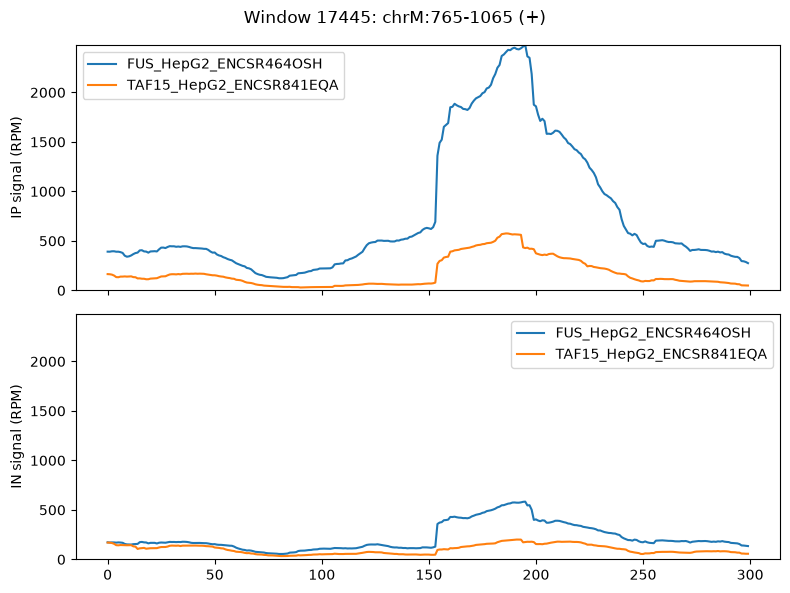

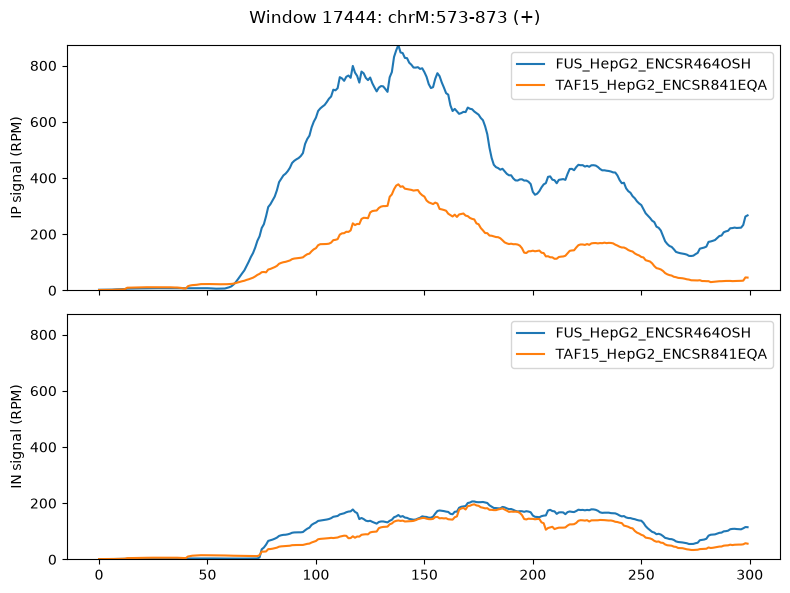

In [116]:
for window_id in top_windows:
    utils.plot_basic_window(window_data, window_id=window_id, experiment_A=experiment_A, experiment_B=experiment_B)

## Basic IN control. 

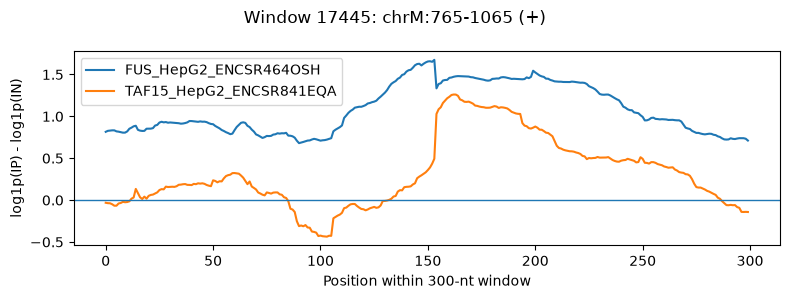

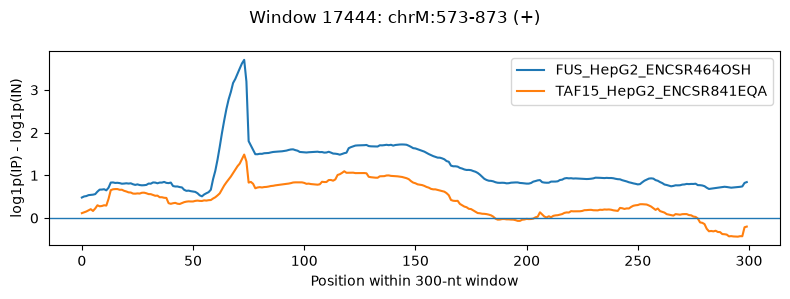

In [98]:
for window_id in top_windows:
    utils.plot_dumb_IN_window(window_data, window_id=window_id, experiment_A=experiment_A, experiment_B=experiment_B)

## IN control with abundance

In [127]:
# Select an alpha value (controls how strong the abundance effect is). 
alpha = 0.0033333333

# Apply the abundance correction.
for window in window_data:
    window["abundance_corrected_A"] = utils.abundance_weighted_enrichment(window["ip_A"], window["in_A"], alpha=alpha)
    window["abundance_corrected_B"] = utils.abundance_weighted_enrichment(window["ip_B"], window["in_B"], alpha=alpha)

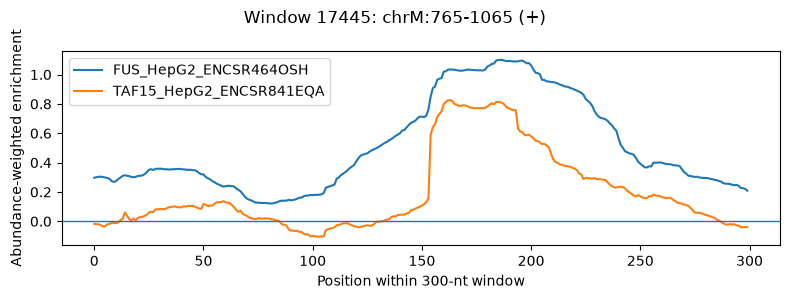

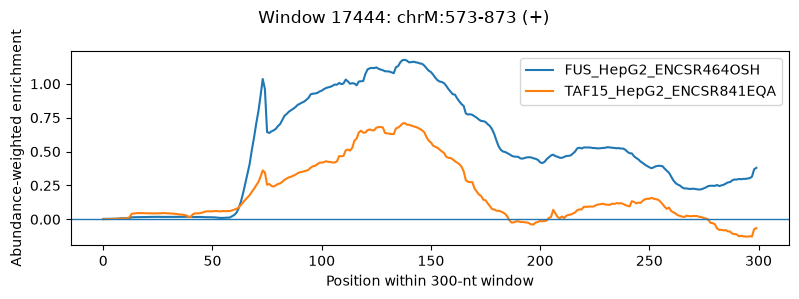

In [128]:
for window_id in top_windows:
    utils.plot_abundance_IN_window(window_data, window_id=window_id, experiment_A=experiment_A, experiment_B=experiment_B)

## Pure variance

In [78]:
for window in window_data:
    window["poisson_variance_A"] = utils.calculate_poisson_variance(window["raw_ip_A"], window["raw_in_A"])
    window["poisson_variance_B"] = utils.calculate_poisson_variance(window["raw_ip_B"], window["raw_in_B"])

In [79]:
def plot_poisson_variance_window(window_data, window_id, experiment_A, experiment_B):
    window = window_data[window_id]
    x = np.arange(len(window["raw_ip_A"]))

    plt.figure(figsize=(8, 3))
    plt.plot(x, window["poisson_variance_A"], label=experiment_A)
    plt.plot(x, window["poisson_variance_B"], label=experiment_B)
    plt.ylabel("Poisson variance")
    plt.xlabel("Position within 300-nt window")
    plt.title(f"Window {window_id}: {window['chr']}:{window['start']}-{window['end']} ({window['strand']})")
    plt.legend()
    plt.tight_layout()
    plt.show()

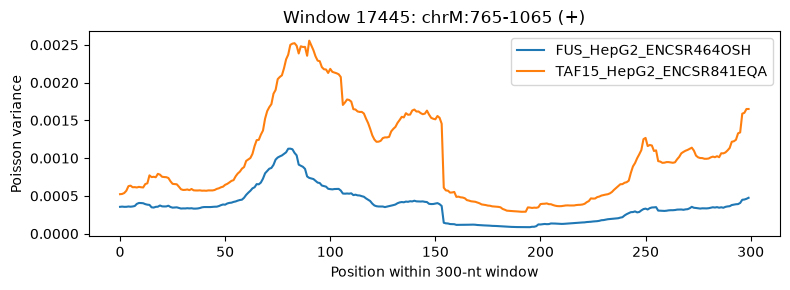

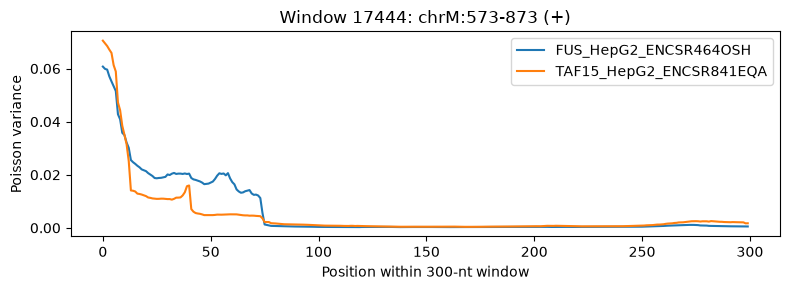

In [80]:
for window_id in top_windows:
    plot_poisson_variance_window(window_data, window_id, experiment_A, experiment_B)

## IN control with basic Shrinkage

In [129]:
tau2 = 0.010

for window in window_data:
    log_enrichment_A = utils.calculate_log_enrichment(
        window["raw_ip_A"], window["raw_in_A"], ip_A_library_size, in_A_library_size
    )
    log_enrichment_B = utils.calculate_log_enrichment(
        window["raw_ip_B"], window["raw_in_B"], ip_B_library_size, in_B_library_size
    )

    variance_A = utils.calculate_poisson_variance(window["raw_ip_A"], window["raw_in_A"])
    variance_B = utils.calculate_poisson_variance(window["raw_ip_B"], window["raw_in_B"])

    window["shrunken_A"] = utils.calculate_shrunken_enrichment(log_enrichment_A, variance_A, tau2)
    window["shrunken_B"] = utils.calculate_shrunken_enrichment(log_enrichment_B, variance_B, tau2)

In [130]:
def plot_shrunken_IN_window(window_data, window_id, experiment_A, experiment_B):
    window = window_data[window_id]
    x = np.arange(len(window["shrunken_A"]))

    plt.figure(figsize=(8, 3))
    plt.plot(x, window["shrunken_A"], label=experiment_A)
    plt.plot(x, window["shrunken_B"], label=experiment_B)
    plt.axhline(0, linewidth=1)
    plt.ylabel("Shrunken log enrichment")
    plt.xlabel("Position within 300-nt window")
    plt.title(f"Window {window_id}: {window['chr']}:{window['start']}-{window['end']} ({window['strand']})")
    plt.legend()
    plt.tight_layout()
    plt.show()

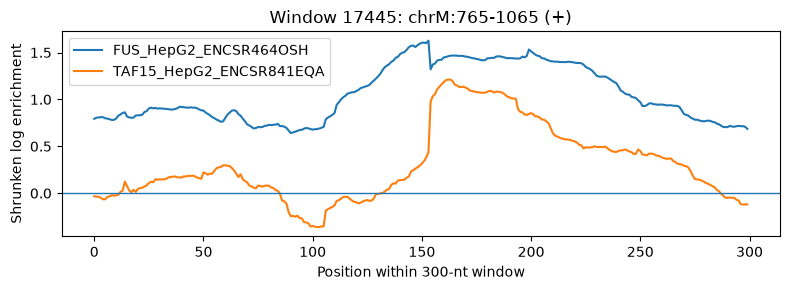

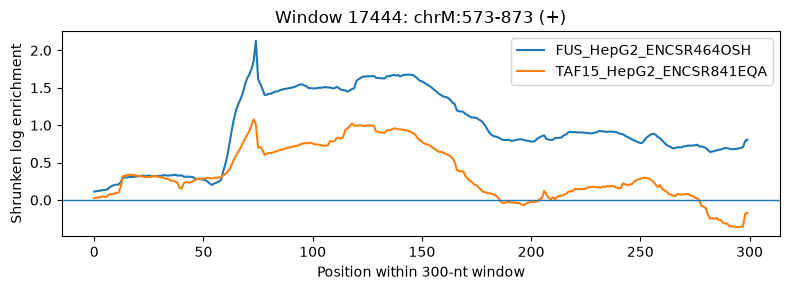

In [131]:
for window_id in top_windows:
    plot_shrunken_IN_window(window_data, window_id, experiment_A, experiment_B)

## IN control with bayesion shrinkage (defunct). 

In [13]:
# Extract out the mean library sizes (where applicable). 
ip_A_library_size = np.mean([library_sizes["IP_A_1"], library_sizes["IP_A_2"]])
in_A_library_size = library_sizes["IN_A_1"]
ip_B_library_size = np.mean([library_sizes["IP_B_1"],library_sizes["IP_B_2"]])
in_B_library_size = library_sizes["IN_B_1"]

In [14]:
# Apply the shrinkage. 
for window in window_data:
    (window["shrunken_A"], window["binomial_log_enrichment_A"], window["shrinkage_A"], window["prior_variance_A"]
    ) = utils.binomial_shrunken_enrichment(window["raw_ip_A"], window["raw_in_A"], ip_library_size=ip_A_library_size,
                                           in_library_size=in_A_library_size, prior_scale=0.01)

    (window["shrunken_B"], window["binomial_log_enrichment_B"], window["shrinkage_B"], window["prior_variance_B"]
    ) = utils.binomial_shrunken_enrichment(window["raw_ip_B"], window["raw_in_B"], ip_library_size=ip_B_library_size, 
                                           in_library_size=in_B_library_size, prior_scale=0.01)

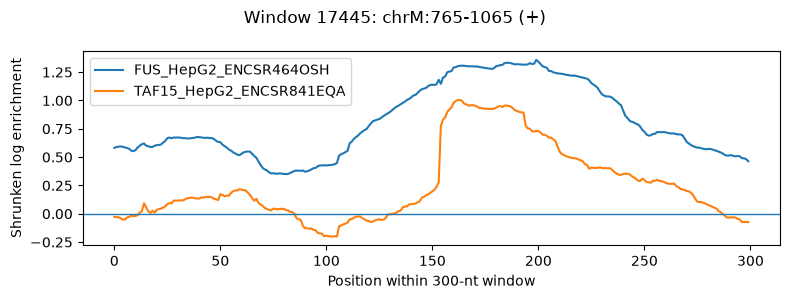

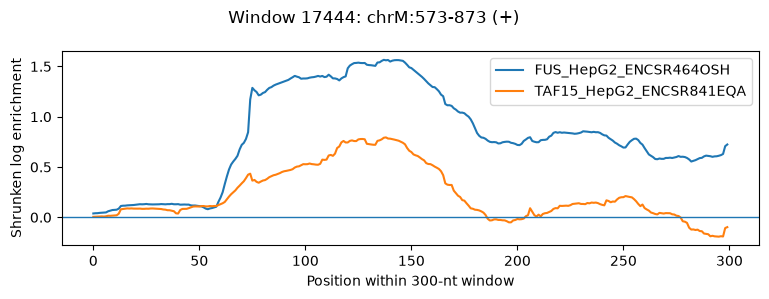

In [15]:
for window_id in top_windows:
    utils.plot_shrunken_IN_window(window_data, window_id=window_id, experiment_A=experiment_A, experiment_B=experiment_B)

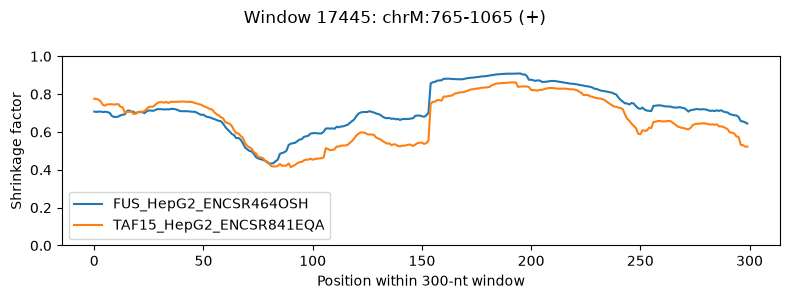

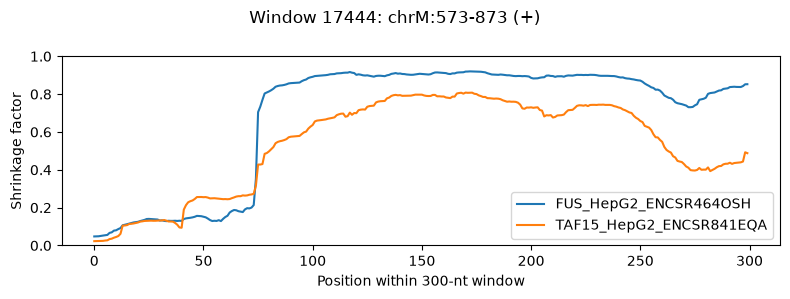

In [16]:
for window_id in top_windows:
    utils.plot_shrinkage_window(window_data, window_id=window_id, experiment_A=experiment_A, experiment_B=experiment_B)